In [19]:
from EXPERIMENT_HYPER_EMPIRICAL import *
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
import matplotlib.colors as colors
from matplotlib.cm import ScalarMappable
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from scipy.sparse import diags, csc_matrix
import hypergraphx as hgx
from _HyperCommunityDetection import *
from hypergraphx.viz import draw_communities
from hypergraphx.viz.draw_hypergraph import draw_hypergraph
import warnings
import pandas as pd
import seaborn as sns
from matplotlib.ticker import MaxNLocator
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

In [3]:
class visual_community:
    def __init__(self, partition, meta):
        self.partition = partition
        self.meta= meta

    def reorder_partition(self, uniqueMeta=None):
        cm, _ = self.PartitionMetaCM(self.partition, self.meta)
        uniquePartition = np.unique(self.partition)
        uniqueMeta = np.unique(self.meta) if uniqueMeta is None else uniqueMeta
        partition_score = np.zeros(np.size(uniquePartition))
        for i in range(np.size(uniquePartition)):
            morelikely_j = np.argmax(cm[i, :])
            partition_score[i] = morelikely_j
            # for j in range(np.size(uniqueMeta)):
            #     partition_score[i] += (j+1) * cm[j, i]
        sort_index = np.argsort(partition_score)
        partition_map = dict()
        for i in range(np.size(sort_index)):
            partition_map[sort_index[i]] = i
        reorder_partition = np.zeros(np.size(self.partition))
        for i in range(np.size(self.partition)):
            reorder_partition[i] = partition_map[self.partition[i]]
        return reorder_partition, partition_score[sort_index]

    @staticmethod
    def PartitionMetaCM(partition, meta, metaFirst=False):
        partition_num = np.size(np.unique(partition))
        meta_num = np.size(np.unique(meta))
        cm = np.zeros((partition_num, meta_num))
        uniquePartition = np.unique(partition)
        uniqueMeta = np.unique(meta)
        for iP in uniquePartition:
            trueIndex = np.where(partition == iP)[0]
            for iM in uniqueMeta:
                i = np.where(uniquePartition == iP)
                j = np.where(uniqueMeta == iM)
                # print(meta, trueIndex)
                if metaFirst:
                    cm[j, i] = np.size(np.where(meta[trueIndex]==iM))
                else:
                    cm[i, j] = np.size(np.where(meta[trueIndex]==iM))
        df = pandas.DataFrame(cm, uniquePartition, uniqueMeta)
        return cm, df

    @staticmethod
    def plot_cm(cm, meta_labels, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(6, 6))
        # cmap = mpl.colormaps["seismic_r"]
        cmap = mpl.colormaps["PuRd"]
        cmap = truncate_colormap(cmap, 0.3, 0.7)
        rowsum = np.sum(cm, axis=1)
        rowsum = rowsum.reshape(-1, 1)
        rowsum = np.repeat(rowsum, np.shape(cm)[1], axis=1)
        norm_cm = np.round(cm / rowsum, 2)
        print(cm)
        ax.matshow(norm_cm, cmap=cmap, vmin=0, vmax=np.max(norm_cm))
        for i in range(np.shape(cm)[0]):
            for j in range(np.shape(cm)[1]):
                c = norm_cm[i,j]
                ax.text(j, i, str(np.round(c, 3) if c != 0 else 0), va='center', ha='center', fontsize=14)
        ax.set_xticks(np.arange(0, np.shape(cm)[1]), np.arange(0, np.shape(cm)[1]), fontsize=20)
        ax.set_yticks(np.arange(0, np.shape(cm)[0]), meta_labels, fontsize=20)

# High School

In [4]:
name = 'highschool'
ehg = EmpiricalHyperGraph(name)
givenNumGroup = 9
only_assortative = True
edge_order, edge_count = np.unique(ehg.H.sum(axis=0).flatten(), return_counts=True)
order_count = dict(zip(edge_order, edge_count))
print(order_count)
partition_path = f'./result/hyperEmpirical/{name}_BHPartition' \
                f'{f"_given{givenNumGroup}Groups" if givenNumGroup is not None else ""}' \
                f'{f"_assort" if only_assortative else ""}.pkl'
with open(partition_path, 'rb') as fr:
    high_BHpartition = pickle.load(fr)

high_meta = []
with open('./net_data/contact-high-school/highschool_data.pkl', 'rb') as fr:
    _data = pickle.load(fr)
    for i in range(_data['n']):
        high_meta.append(_data['meta'][i])
unique_highmeta = np.unique(high_meta)
meta_name_map = {m:np.where(unique_highmeta==m)[0][0] for m in unique_highmeta}
high_meta = [meta_name_map[m] for m in high_meta]
high_meta = np.array(high_meta)
# print(meta_name_map, unique_highmeta)

Construct highschool hypergraph with 327 nodes, 7818 hyperedges and all possible k is [3, 4, 2, 5].
{2: 5498, 3: 2091, 4: 222, 5: 7}


D:\BackProgram\Anaconda\envs\network\Lib\site-packages\matplotlib_inline\config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


[[33.  0.  0.  0.  0.  3.  0.  0.  0.]
 [ 0. 25.  0.  0.  0.  9.  0.  0.  0.]
 [ 0.  1. 19. 14.  0.  6.  0.  0.  0.]
 [ 0.  0.  0.  0. 28.  5.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. 28.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. 37.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. 12. 32.  0.  0.]
 [ 0.  0.  0.  0.  0. 10.  0. 29.  0.]
 [ 0.  0.  0.  0.  0.  8.  0.  0. 26.]]


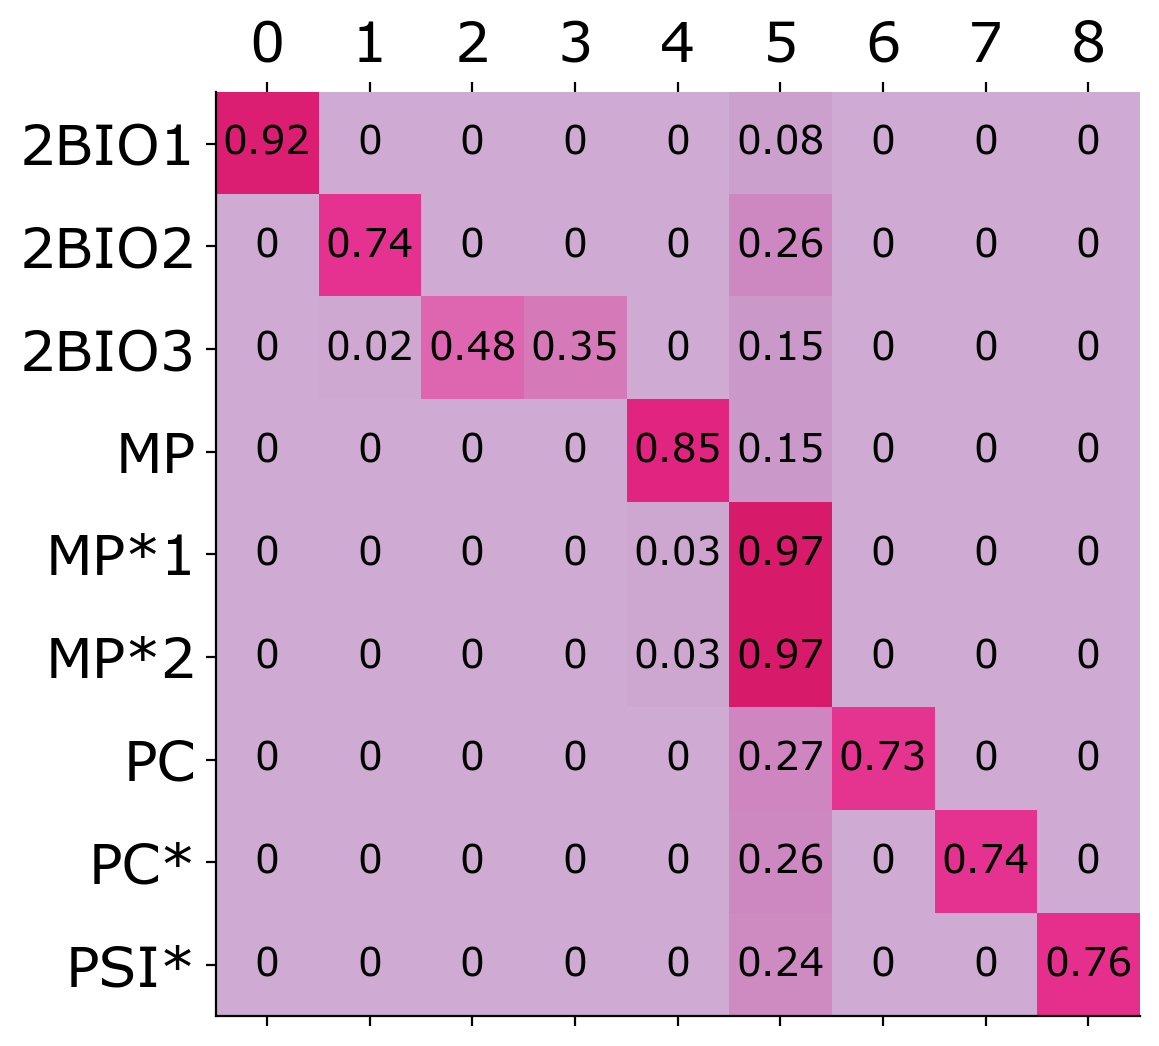

In [5]:
vc = visual_community(high_BHpartition, high_meta)
re_high_partition, _ = vc.reorder_partition(uniqueMeta=unique_highmeta)
cm, _ = vc.PartitionMetaCM(re_high_partition, high_meta, metaFirst=True)
vc.plot_cm(cm, meta_labels=unique_highmeta)

## Check BH Partition for different orders

{2: 5498, 3: 2091, 4: 222, 5: 7}


Construct $BH_8.97601288654654$: 100%|██████████████████████████████████████████████████| 2/2 [00:00<00:00, 333.24it/s]

Combined evals: [-8.21531383 -7.57786479 -6.44397639 -5.61432053 -5.28650098 -4.96636119
 -3.79128928 -3.14157412 -2.59540934], select 9 groups for assortative, select 0 groups for disassortative
EVECs construct: 0.012994050979614258
Bethe Hessian detect 9 communities in network highschool
[[34.  0.  0.  0.  0.  2.  0.  0.  0.]
 [ 0. 28.  0.  0.  0.  6.  0.  0.  0.]
 [ 0.  1. 19. 14.  0.  6.  0.  0.  0.]
 [ 0.  0.  0.  0. 29.  4.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. 28.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. 37.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  9. 35.  0.  0.]
 [ 0.  0.  0.  0.  0.  7.  0. 32.  0.]
 [ 0.  0.  0.  0.  0.  5.  0.  0. 29.]]


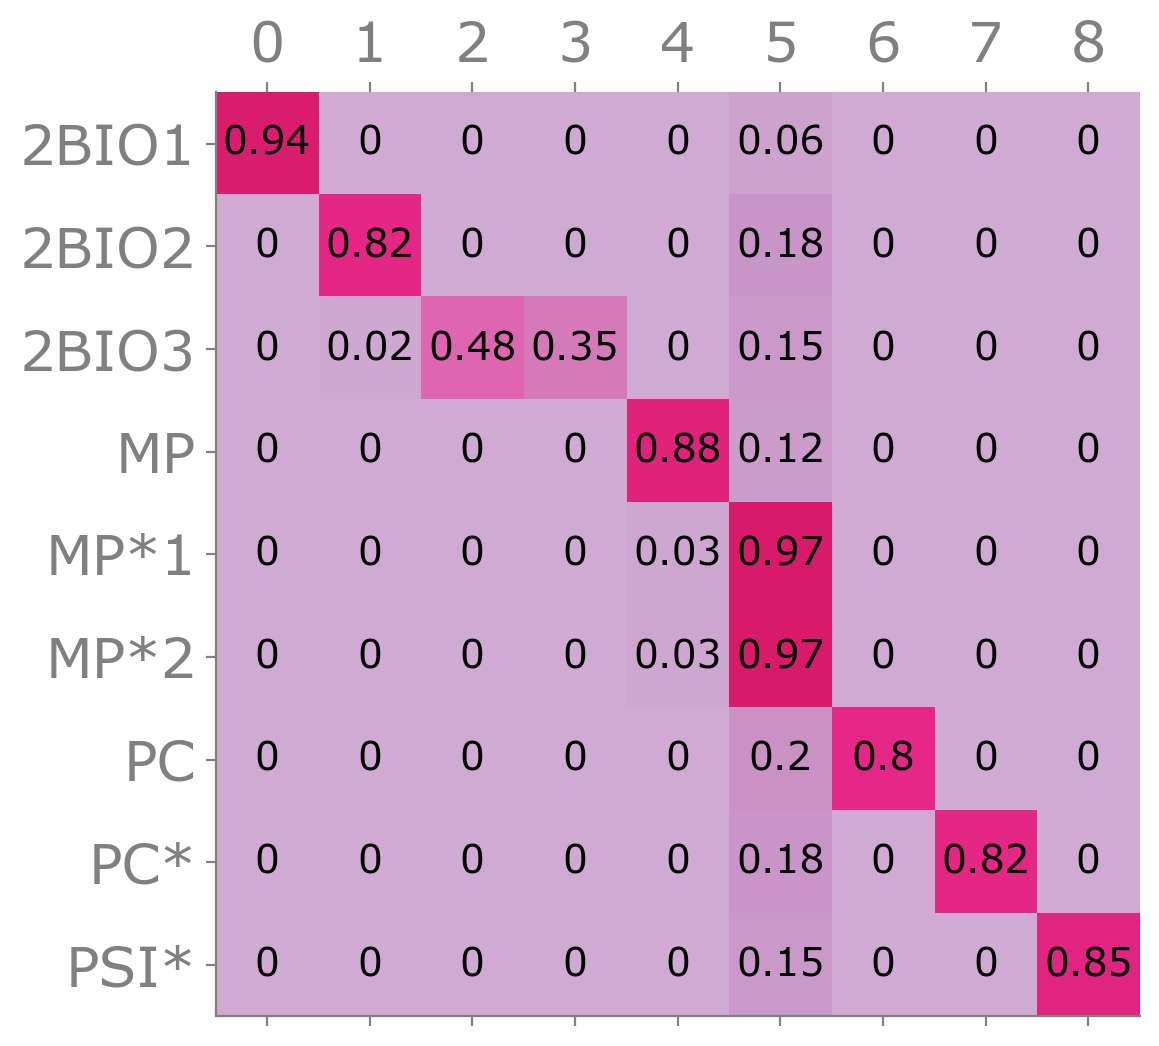

In [47]:
partition, _ = cd(ehg, save_path=None, visual_path=None, redetect=True, only_assortative=True, givenNumGroup=9, consider_ks=[2, 3], dc=False)
vc = visual_community(partition, high_meta)
re_partition, _ = vc.reorder_partition(uniqueMeta=unique_highmeta)
cm, _ = vc.PartitionMetaCM(re_partition, high_meta, metaFirst=True)
vc.plot_cm(cm, meta_labels=unique_highmeta)

## Observe diff shape 3-hyperedges between groups of partition or meta

In [63]:
k = 3
edge_order = ehg.H.sum(axis=0).flatten()
edge_index = np.where(edge_order == k)[0]
Hk = ehg.H[:, edge_index]

partition_num = np.size(np.unique(re_partition))
meta_num = np.size(np.unique(high_meta))
# The number of 3-hyperedges connect 2 group (Triaugular shape connection between 2 group)
connection_2_p = np.zeros((partition_num, partition_num)).astype(int)
connection_2_m = np.zeros((meta_num, meta_num)).astype(int)
# The number of 3-hyperedges connect 3 group (Line shape connection between 2 group)
connection_3_p = np.zeros((partition_num, partition_num)).astype(int)
connection_3_m = np.zeros((meta_num, meta_num)).astype(int)

for ei in range(np.shape(Hk)[1]):
    # print(Hk[:, [ei]])
    nodes = np.where(Hk[:, [ei]].toarray()!=0)[0]
    # print(nodes)
    p_labels = np.array([re_partition[ni] for ni in nodes])
    m_labels = np.array([high_meta[ni] for ni in nodes])
    # print(p_labels)
    unique_p_label = np.unique(p_labels).astype(int)
    if np.size(unique_p_label) == 1:
        l = unique_p_label[0]
        connection_2_p[l, l] += 1
        connection_3_p[l, l] += 1
    if np.size(unique_p_label) == 2:
        l1, l2 = unique_p_label[0], unique_p_label[1]
        connection_2_p[l1, l2] += 1
        connection_2_p[l2, l1] += 1
    if np.size(unique_p_label) == 3:
        l1, l2, l3 = unique_p_label[0], unique_p_label[1], unique_p_label[2]
        connection_3_p[l1, l2] += 1
        connection_3_p[l2, l1] += 1
        connection_3_p[l1, l3] += 1
        connection_3_p[l3, l1] += 1
        connection_3_p[l3, l2] += 1
        connection_3_p[l2, l3] += 1
    unique_m_label = np.unique(m_labels).astype(int)
    if np.size(unique_m_label) == 1:
        l = unique_m_label[0]
        connection_2_m[l, l] += 1
        connection_3_m[l, l] += 1
    if np.size(unique_m_label) == 2:
        l1, l2 = unique_m_label[0], unique_m_label[1]
        connection_2_m[l1, l2] += 1
        connection_2_m[l2, l1] += 1
    if np.size(unique_m_label) == 3:
        l1, l2, l3 = unique_m_label[0], unique_m_label[1], unique_m_label[2]
        connection_3_m[l1, l2] += 1
        connection_3_m[l2, l1] += 1
        connection_3_m[l1, l3] += 1
        connection_3_m[l3, l1] += 1
        connection_3_m[l3, l2] += 1
        connection_3_m[l2, l3] += 1

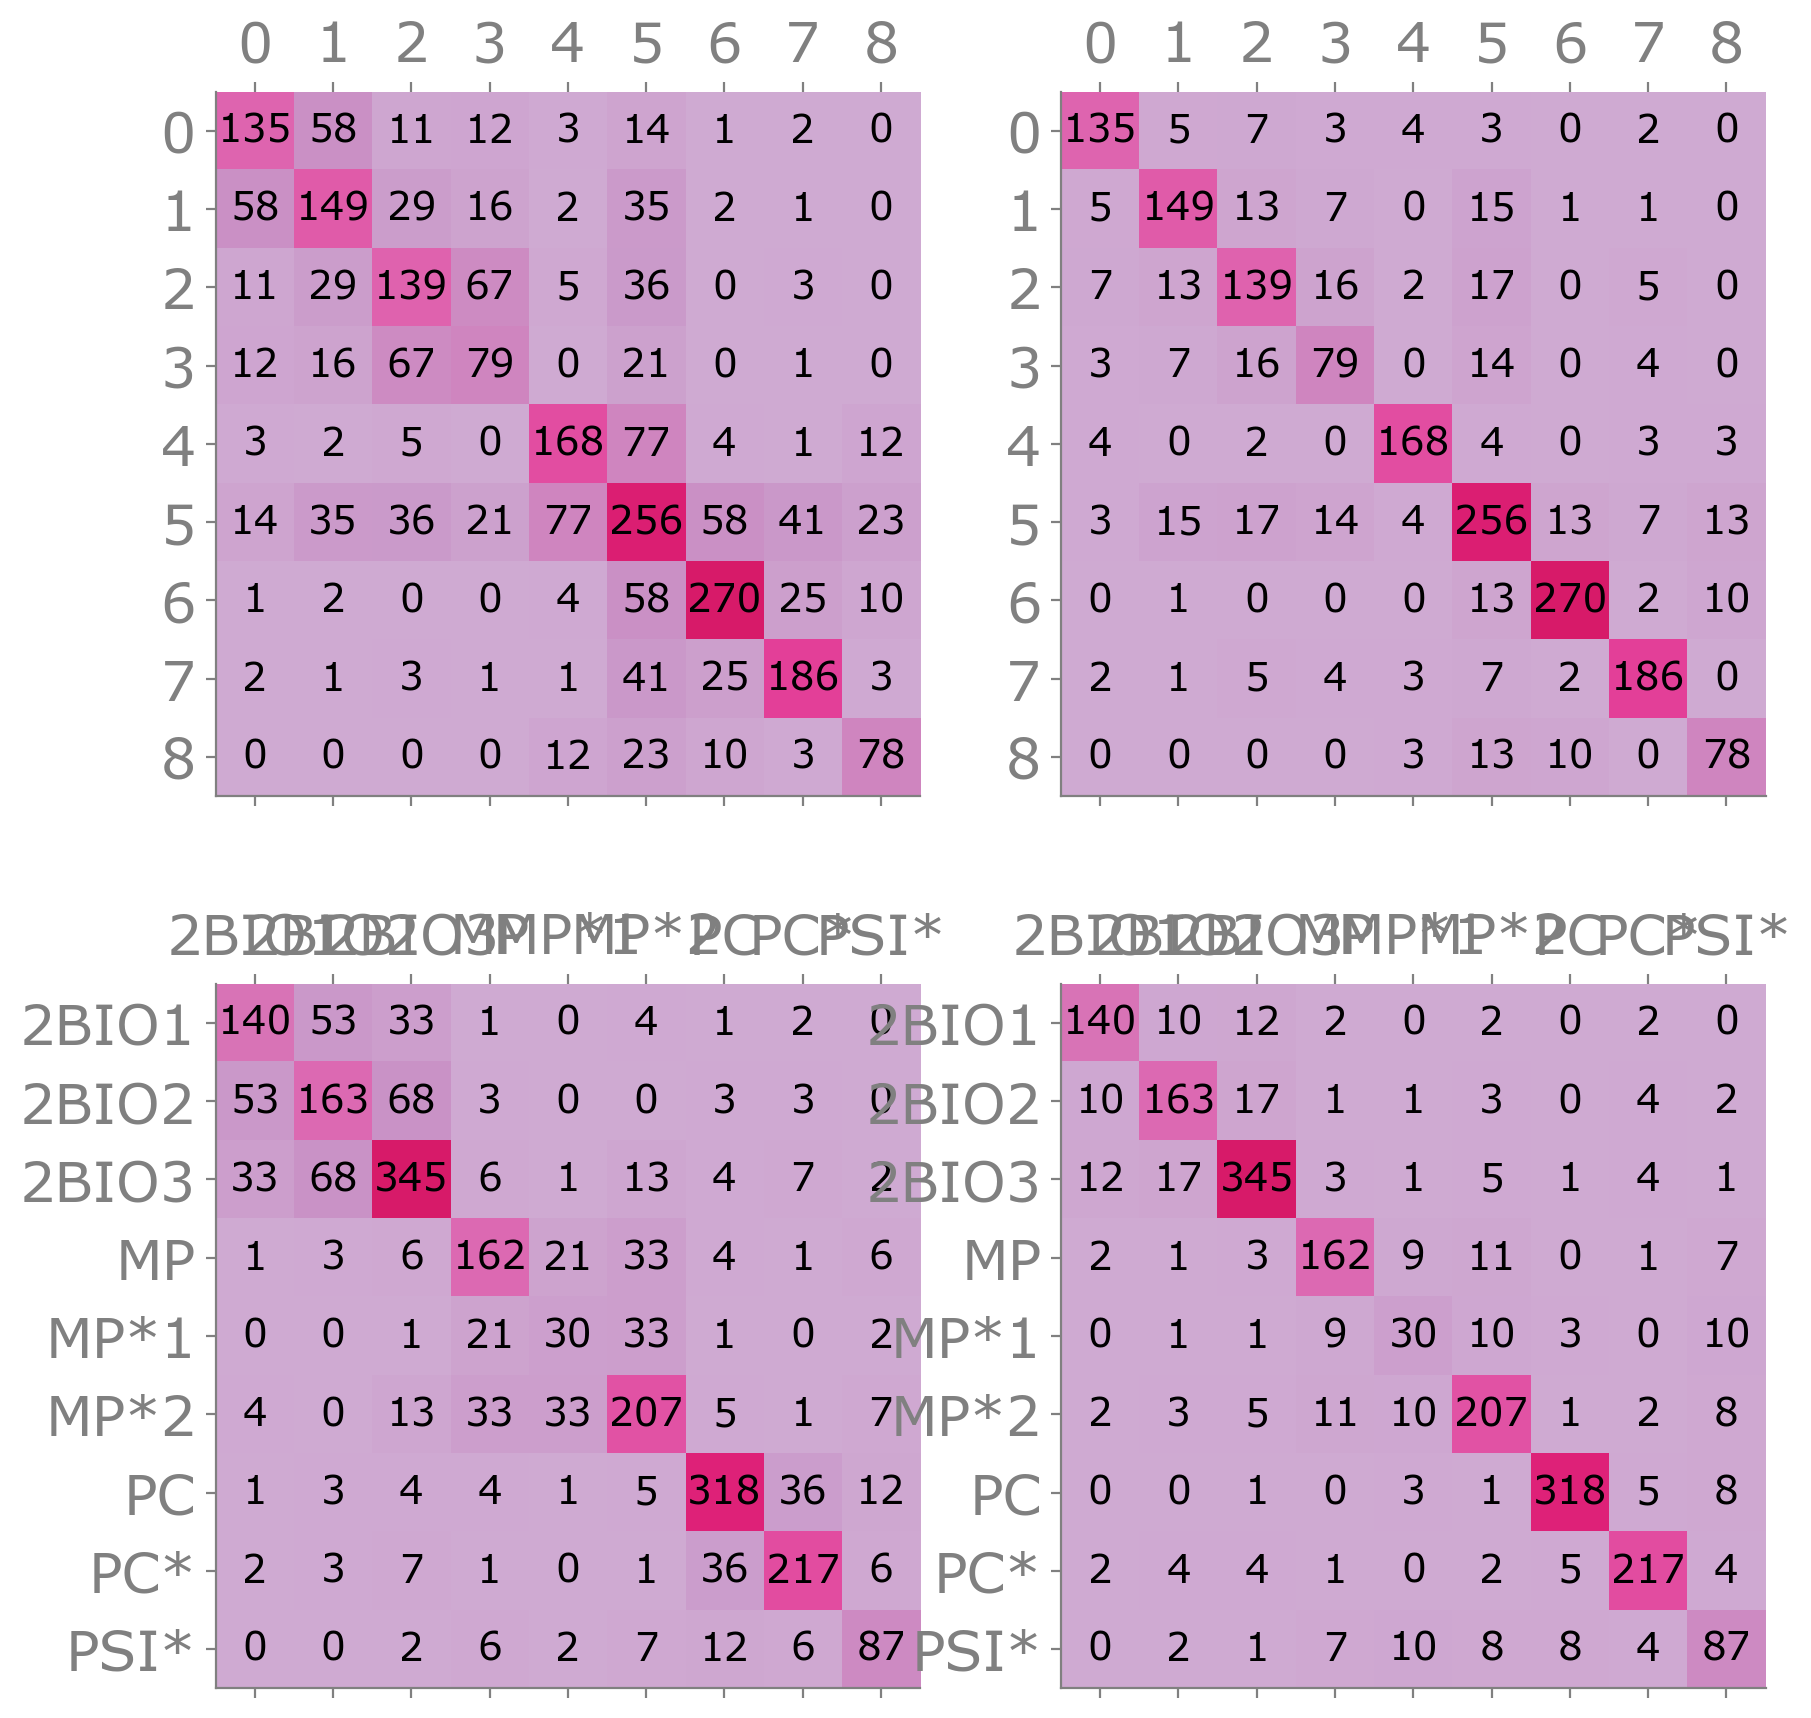

In [65]:
fig = plt.figure(figsize=(10, 28))
widths = [5, 5]
heights = [5, 5, 5, 5, 5]
spec5 = fig.add_gridspec(ncols=2, nrows=5, width_ratios=widths, height_ratios=heights)

row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["PuRd"]
cmap = truncate_colormap(cmap, 0.3, 0.7)
ax.matshow(connection_2_p, cmap=cmap, vmin=0, vmax=np.max(connection_2_p))
for i in range(partition_num):
    for j in range(partition_num):
        c = connection_2_p[i,j]
        ax.text(j, i, str(np.round(c, 3) if c != 0 else 0), va='center', ha='center', fontsize=14)
ax.set_xticks(np.arange(0, partition_num), np.arange(0, partition_num), fontsize=20)
ax.set_yticks(np.arange(0, partition_num), np.arange(0, partition_num), fontsize=20)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["PuRd"]
cmap = truncate_colormap(cmap, 0.3, 0.7)
ax.matshow(connection_3_p, cmap=cmap, vmin=0, vmax=np.max(connection_3_p))
for i in range(partition_num):
    for j in range(partition_num):
        c = connection_3_p[i,j]
        ax.text(j, i, str(np.round(c, 3) if c != 0 else 0), va='center', ha='center', fontsize=14)
ax.set_xticks(np.arange(0, partition_num), np.arange(0, partition_num), fontsize=20)
ax.set_yticks(np.arange(0, partition_num), np.arange(0, partition_num), fontsize=20)

row = 1
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["PuRd"]
cmap = truncate_colormap(cmap, 0.3, 0.7)
ax.matshow(connection_2_m, cmap=cmap, vmin=0, vmax=np.max(connection_2_m))
for i in range(meta_num):
    for j in range(meta_num):
        c = connection_2_m[i,j]
        ax.text(j, i, str(np.round(c, 3) if c != 0 else 0), va='center', ha='center', fontsize=14)
ax.set_xticks(np.arange(0, meta_num), unique_highmeta, fontsize=20)
ax.set_yticks(np.arange(0, meta_num), unique_highmeta, fontsize=20)

row = 1
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["PuRd"]
cmap = truncate_colormap(cmap, 0.3, 0.7)
ax.matshow(connection_3_m, cmap=cmap, vmin=0, vmax=np.max(connection_3_m))
for i in range(meta_num):
    for j in range(meta_num):
        c = connection_3_m[i,j]
        ax.text(j, i, str(np.round(c, 3) if c != 0 else 0), va='center', ha='center', fontsize=14)
ax.set_xticks(np.arange(0, meta_num), unique_highmeta, fontsize=20)
ax.set_yticks(np.arange(0, meta_num), unique_highmeta, fontsize=20)

## Degree Distribution

In [74]:
name = 'highschool'
ehg = EmpiricalHyperGraph(name)
vc = visual_community(high_BHpartition, high_meta)
re_partition, _ = vc.reorder_partition(uniqueMeta=unique_highmeta)

records = []
for i in range(ehg.n):
    meta_l = high_meta[i]
    bh_l = int(re_partition[i])
    
    # 组合键
    group_key = f'{meta_l}_{bh_l}'
    
    # 获取节点 i 关联的边索引
    # [0] 表示只获取行索引，由于是 ehg.H[[i], :]，所以行索引总是 0
    edge_index = ehg.H[[i], :].nonzero()[1]
    
    # 计算这些边的 order 和 degree counts
    # order 对应的是 边的度 (degree)
    # degree_counts 对应的是 该度值出现的次数
    # 注意：这里计算的是连接到节点 i 的这些边，在整个超图中的度分布。
    order, degree_counts = np.unique(ehg.H[:, edge_index].sum(axis=0).flatten(), return_counts=True)
    
    # 遍历 order 和 degree_counts，将数据添加到 records 列表
    for (o, d_count) in zip(order, degree_counts):
        # 记录每条记录
        record = {
            'Node_Index': i,                      # 当前节点索引
            'Meta_Label': meta_l,                 # 节点元信息
            'Community_ID': bh_l,                 # 节点所在社区 ID
            'Group_Key': group_key,               # 组合键 (Meta_Label_Community_ID)
            'Edge_Order': o,                      # 边的度 (Order)
            'Order_Degree': d_count,               # 该 Order 出现的次数
            'Total_Degree': np.sum(degree_counts) # 该节点总边数 (degree)
        }
        records.append(record)

# 2. 将记录列表转换为 DataFrame
df_degree_distribution = pd.DataFrame(records)

Construct highschool hypergraph with 327 nodes, 7818 hyperedges and all possible k is [3, 4, 2, 5].


In [120]:
print(df_degree_distribution['Group_Key'])
print(meta_name_map)

0      3_4
1      3_4
2      3_4
3      3_4
4      3_4
      ... 
895    8_8
896    8_8
897    8_8
898    4_5
899    4_5
Name: Group_Key, Length: 900, dtype: object
{'2BIO1': 0, '2BIO2': 1, '2BIO3': 2, 'MP': 3, 'MP*1': 4, 'MP*2': 5, 'PC': 6, 'PC*': 7, 'PSI*': 8}


In [117]:
def plot_grouped_degree_distribution(
    df: pd.DataFrame,
    group_type: str,            # 'Meta_Label' 或 'Community_ID'
    group_list: list,           # 要筛选的 Meta 或 Community ID 列表
    order_list: list = None,    # 要筛选的 Edge_Order 列表 (None 表示所有 Order)
    ax = None,
    label = ""
):
    """
    根据给定的 Meta 或 Community ID，绘制特定 Order 的度分布。
    
    Args:
        df: 包含度分布信息的 DataFrame。
        group_type: 用于筛选的列名 ('Meta_Label' 或 'Community_ID')。
        group_list: 要包含的 Meta 或 Community ID 列表。
        order_list: 要包含的 Edge_Order 列表。None 表示包含所有 Order。
    """
    if group_type not in ['Meta_Label', 'Community_ID', 'Group_Key']:
        raise ValueError("group_type 必须是 'Meta_Label' 或 'Community_ID' 或 'Group_Key'")

    # 1. 数据筛选
    df_filtered = df[df[group_type].isin(group_list)].copy()

    if order_list is not None:
        df_filtered = df_filtered[df_filtered['Edge_Order'].isin(order_list)]

    if df_filtered.empty:
        print("警告: 筛选后数据为空，无法绘图。")
        return

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    
    # 使用 Seaborn 绘制分组条形图，清晰地展示分组和类别
    sns.histplot(
        data=df_filtered,
        x='Order_Degree',
        binwidth=1,
        stat="probability",
        ax=ax,
        label=label
    )
    
    # 设置图表元素
    ax.set_title(f'Order:{",".join([str(o) for o in order_list])}', fontsize=16)
    ax.set_xlabel('Degree', fontsize=12)
    ax.set_ylabel("Probability", fontsize=12)
    ax.legend()

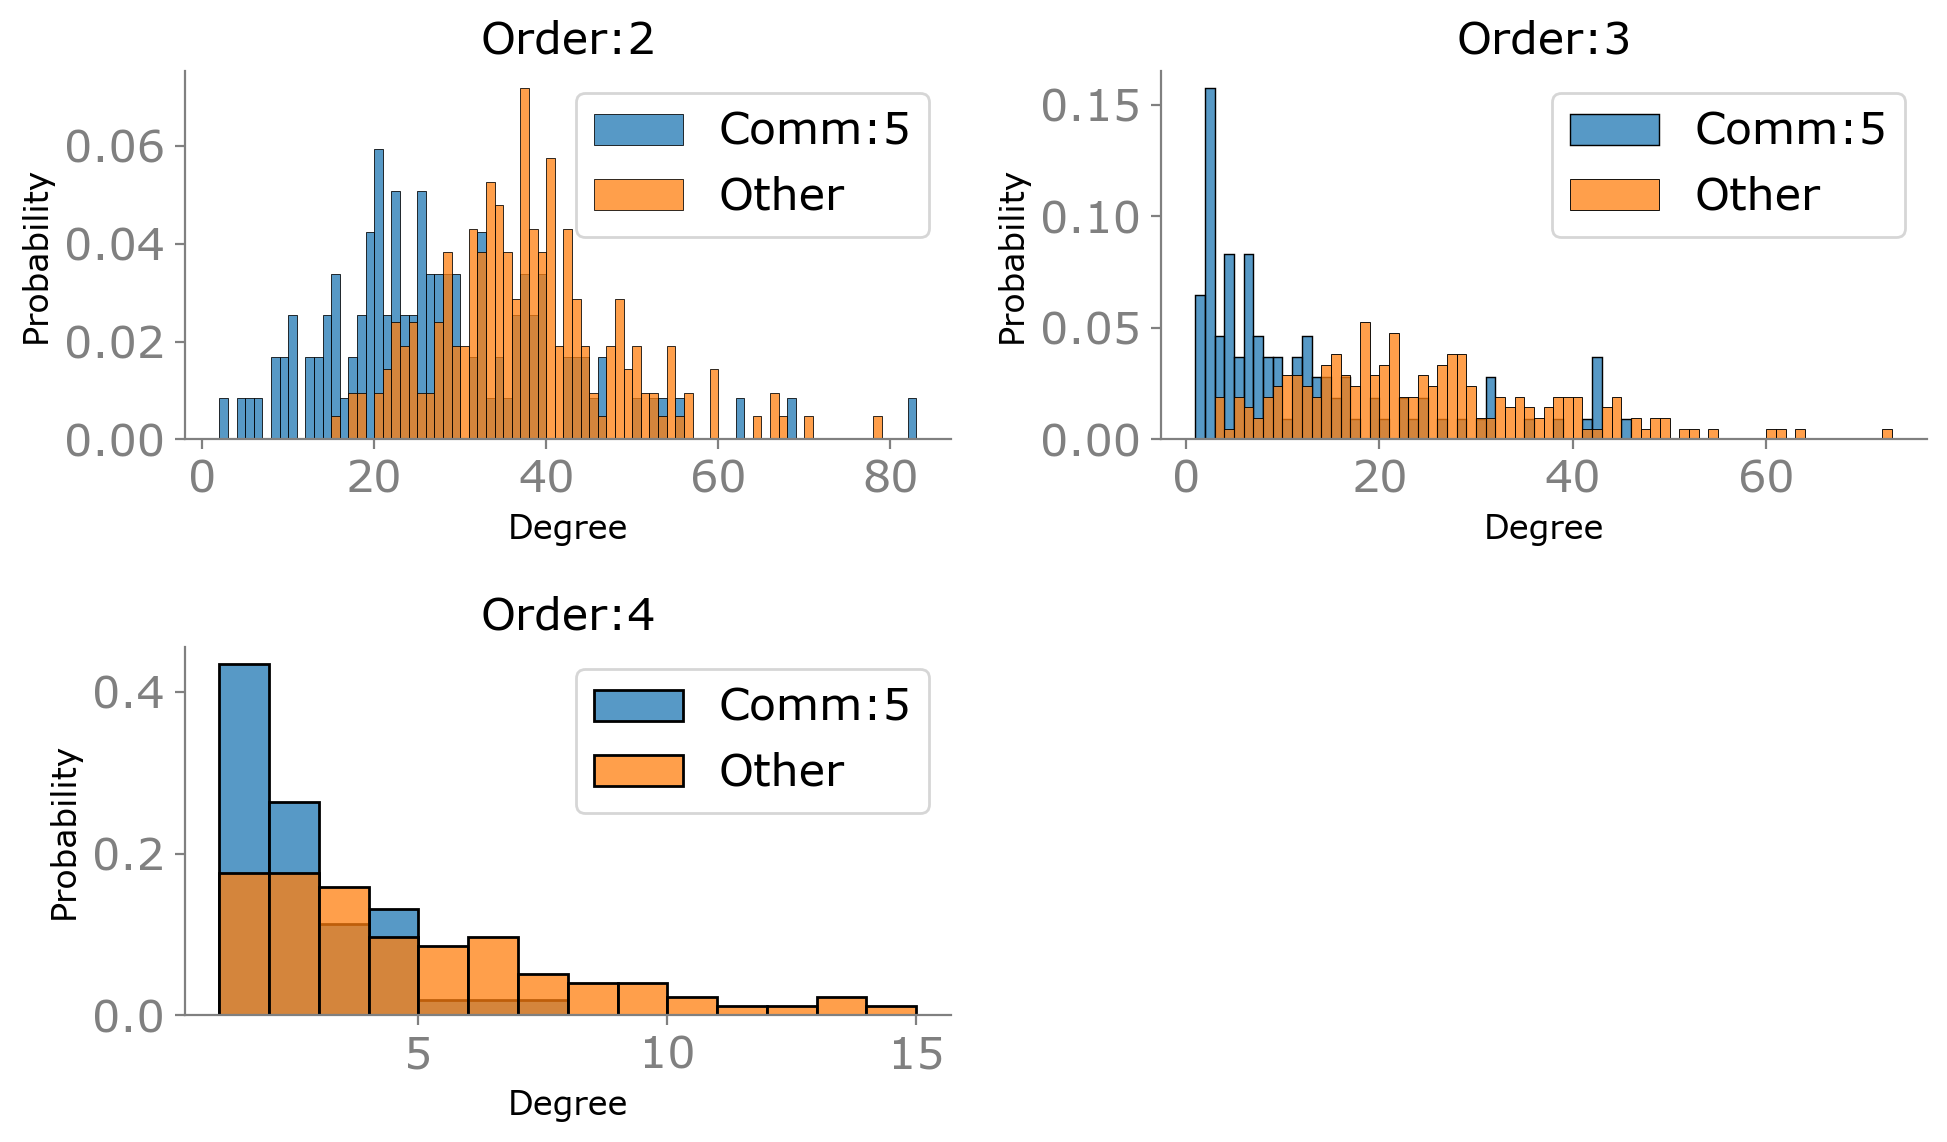

In [116]:
fig = plt.figure(figsize=(10, 6))
widths = [5, 5]
heights = [5, 5]
spec5 = fig.add_gridspec(ncols=2, nrows=2, width_ratios=widths, height_ratios=heights)

row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
plot_grouped_degree_distribution(
    df=df_degree_distribution,
    group_type="Community_ID",           # 'Meta_Label' 或 'Community_ID'
    group_list = [5],           # 要筛选的 Meta 或 Community ID 列表
    order_list = [2],    # 要筛选的 Edge_Order 列表 (None 表示所有 Order)
    ax = ax, 
    label = "Comm:5"
)
plot_grouped_degree_distribution(
    df=df_degree_distribution,
    group_type="Community_ID",           # 'Meta_Label' 或 'Community_ID'
    group_list = [0, 1, 2, 3, 4, 6, 7, 8],           # 要筛选的 Meta 或 Community ID 列表
    order_list = [2],    # 要筛选的 Edge_Order 列表 (None 表示所有 Order)
    ax = ax, 
    label = "Other"
)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
plot_grouped_degree_distribution(
    df=df_degree_distribution,
    group_type="Community_ID",           # 'Meta_Label' 或 'Community_ID'
    group_list = [5],           # 要筛选的 Meta 或 Community ID 列表
    order_list = [3],    # 要筛选的 Edge_Order 列表 (None 表示所有 Order)
    ax = ax, 
    label = "Comm:5"
)
plot_grouped_degree_distribution(
    df=df_degree_distribution,
    group_type="Community_ID",           # 'Meta_Label' 或 'Community_ID'
    group_list = [0, 1, 2, 3, 4, 6, 7, 8],           # 要筛选的 Meta 或 Community ID 列表
    order_list = [3],    # 要筛选的 Edge_Order 列表 (None 表示所有 Order)
    ax = ax, 
    label = "Other"
)

row = 1
col = 0
ax = fig.add_subplot(spec5[row, col])
plot_grouped_degree_distribution(
    df=df_degree_distribution,
    group_type="Community_ID",           # 'Meta_Label' 或 'Community_ID'
    group_list = [5],           # 要筛选的 Meta 或 Community ID 列表
    order_list = [4],    # 要筛选的 Edge_Order 列表 (None 表示所有 Order)
    ax = ax, 
    label = "Comm:5"
)
plot_grouped_degree_distribution(
    df=df_degree_distribution,
    group_type="Community_ID",           # 'Meta_Label' 或 'Community_ID'
    group_list = [0, 1, 2, 3, 4, 6, 7, 8],           # 要筛选的 Meta 或 Community ID 列表
    order_list = [4],    # 要筛选的 Edge_Order 列表 (None 表示所有 Order)
    ax = ax, 
    label = "Other"
)

# row = 1
# col = 1
# ax = fig.add_subplot(spec5[row, col])
# plot_grouped_degree_distribution(
#     df=df_degree_distribution,
#     group_type="Community_ID",           # 'Meta_Label' 或 'Community_ID'
#     group_list = [5],           # 要筛选的 Meta 或 Community ID 列表
#     order_list = [5],    # 要筛选的 Edge_Order 列表 (None 表示所有 Order)
#     ax = ax, 
#     label = "Comm:5"
# )
# plot_grouped_degree_distribution(
#     df=df_degree_distribution,
#     group_type="Community_ID",           # 'Meta_Label' 或 'Community_ID'
#     group_list = [0, 1, 2, 3, 4, 6, 7, 8],           # 要筛选的 Meta 或 Community ID 列表
#     order_list = [5],    # 要筛选的 Edge_Order 列表 (None 表示所有 Order)
#     ax = ax, 
#     label = "Other"
# )

plt.tight_layout()

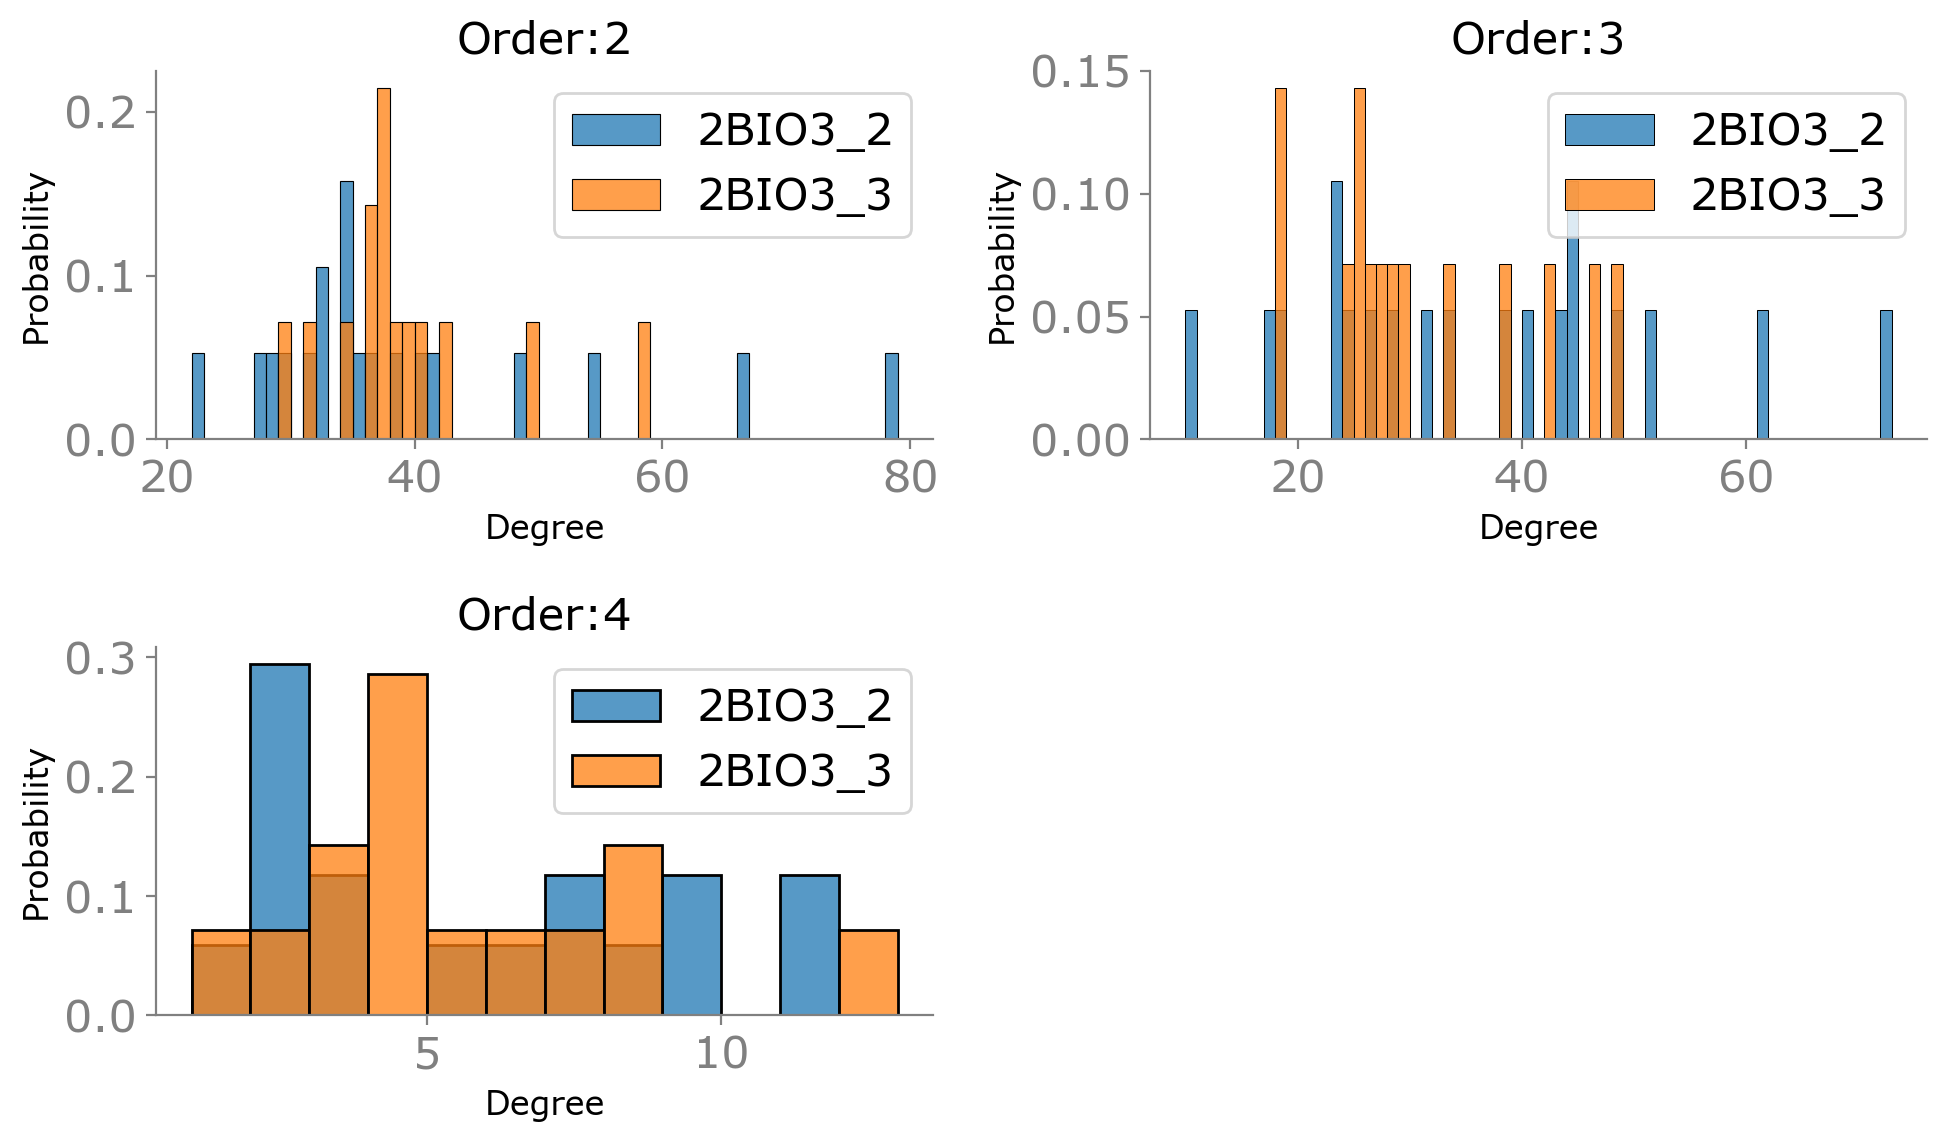

In [126]:
fig = plt.figure(figsize=(10, 6))
widths = [5, 5]
heights = [5, 5]
spec5 = fig.add_gridspec(ncols=2, nrows=2, width_ratios=widths, height_ratios=heights)

row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
plot_grouped_degree_distribution(
    df=df_degree_distribution,
    group_type="Group_Key",           # 'Meta_Label' 或 'Community_ID'
    group_list = ['2_2'],           # 要筛选的 Meta 或 Community ID 列表
    order_list = [2],    # 要筛选的 Edge_Order 列表 (None 表示所有 Order)
    ax = ax, 
    label = "2BIO3_2"
)
plot_grouped_degree_distribution(
    df=df_degree_distribution,
    group_type="Group_Key",           # 'Meta_Label' 或 'Community_ID'
    group_list = ['2_3'],           # 要筛选的 Meta 或 Community ID 列表
    order_list = [2],    # 要筛选的 Edge_Order 列表 (None 表示所有 Order)
    ax = ax, 
    label = "2BIO3_3"
)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
plot_grouped_degree_distribution(
    df=df_degree_distribution,
    group_type="Group_Key",           # 'Meta_Label' 或 'Community_ID'
    group_list = ['2_2'],           # 要筛选的 Meta 或 Community ID 列表
    order_list = [3],    # 要筛选的 Edge_Order 列表 (None 表示所有 Order)
    ax = ax, 
    label = "2BIO3_2"
)
plot_grouped_degree_distribution(
    df=df_degree_distribution,
    group_type="Group_Key",           # 'Meta_Label' 或 'Community_ID'
    group_list = ['2_3'],           # 要筛选的 Meta 或 Community ID 列表
    order_list = [3],    # 要筛选的 Edge_Order 列表 (None 表示所有 Order)
    ax = ax, 
    label = "2BIO3_3"
)

row = 1
col = 0
ax = fig.add_subplot(spec5[row, col])
plot_grouped_degree_distribution(
    df=df_degree_distribution,
    group_type="Group_Key",           # 'Meta_Label' 或 'Community_ID'
    group_list = ['2_2'],           # 要筛选的 Meta 或 Community ID 列表
    order_list = [4],    # 要筛选的 Edge_Order 列表 (None 表示所有 Order)
    ax = ax, 
    label = "2BIO3_2"
)
plot_grouped_degree_distribution(
    df=df_degree_distribution,
    group_type="Group_Key",           # 'Meta_Label' 或 'Community_ID'
    group_list = ['2_3'],           # 要筛选的 Meta 或 Community ID 列表
    order_list = [4],    # 要筛选的 Edge_Order 列表 (None 表示所有 Order)
    ax = ax, 
    label = "2BIO3_3"
)

plt.tight_layout()

## Split Feature of Hyperedges

In [6]:
records = []
orders = ehg.H.sum(axis=0).flatten()
for i in range(ehg.H.shape[1]):
    order = orders[i]
    nodes = np.where(ehg.H[:, [i]].toarray()!=0)[0]
    # print(nodes)
    p_labels = np.array([re_high_partition[ni] for ni in nodes])
    m_labels = np.array([high_meta[ni] for ni in nodes])
    record = {
        'Edge_Index': i,
        'Order': order,
        'Num_Community': np.size(np.unique(p_labels)),
        'MaxNumNodes_SameCommunity': np.max(np.unique(p_labels, return_counts=True)[1]),
        'Num_Class': np.size(np.unique(m_labels)),
        'MaxNumNodes_SameClass': np.max(np.unique(m_labels, return_counts=True)[1]),
    }
    # print(p_labels, np.size(np.unique(p_labels)), np.max(np.unique(p_labels, return_counts=True)[1]))
    records.append(record)
df_hedge_distribution = pd.DataFrame(records)

In [32]:
print(df_hedge_distribution)

      Edge_Index  Order  Num_Community  MaxNumNodes_SameCommunity  Num_Class  \
0              0      3              1                          3          1   
1              1      4              1                          4          1   
2              2      2              1                          2          1   
3              3      2              1                          2          1   
4              4      2              1                          2          1   
...          ...    ...            ...                        ...        ...   
7813        7813      2              1                          2          1   
7814        7814      2              1                          2          1   
7815        7815      2              1                          2          1   
7816        7816      2              1                          2          1   
7817        7817      2              1                          2          1   

      MaxNumNodes_SameClass  
0        

   Order       Split_Type  Count
0      2  Split_Community   2393
1      3  Split_Community    631
2      4  Split_Community     68
3      5  Split_Community      3
4      2      Split_Class   1615
5      3      Split_Class    422
6      4      Split_Class     59
7      5      Split_Class      2


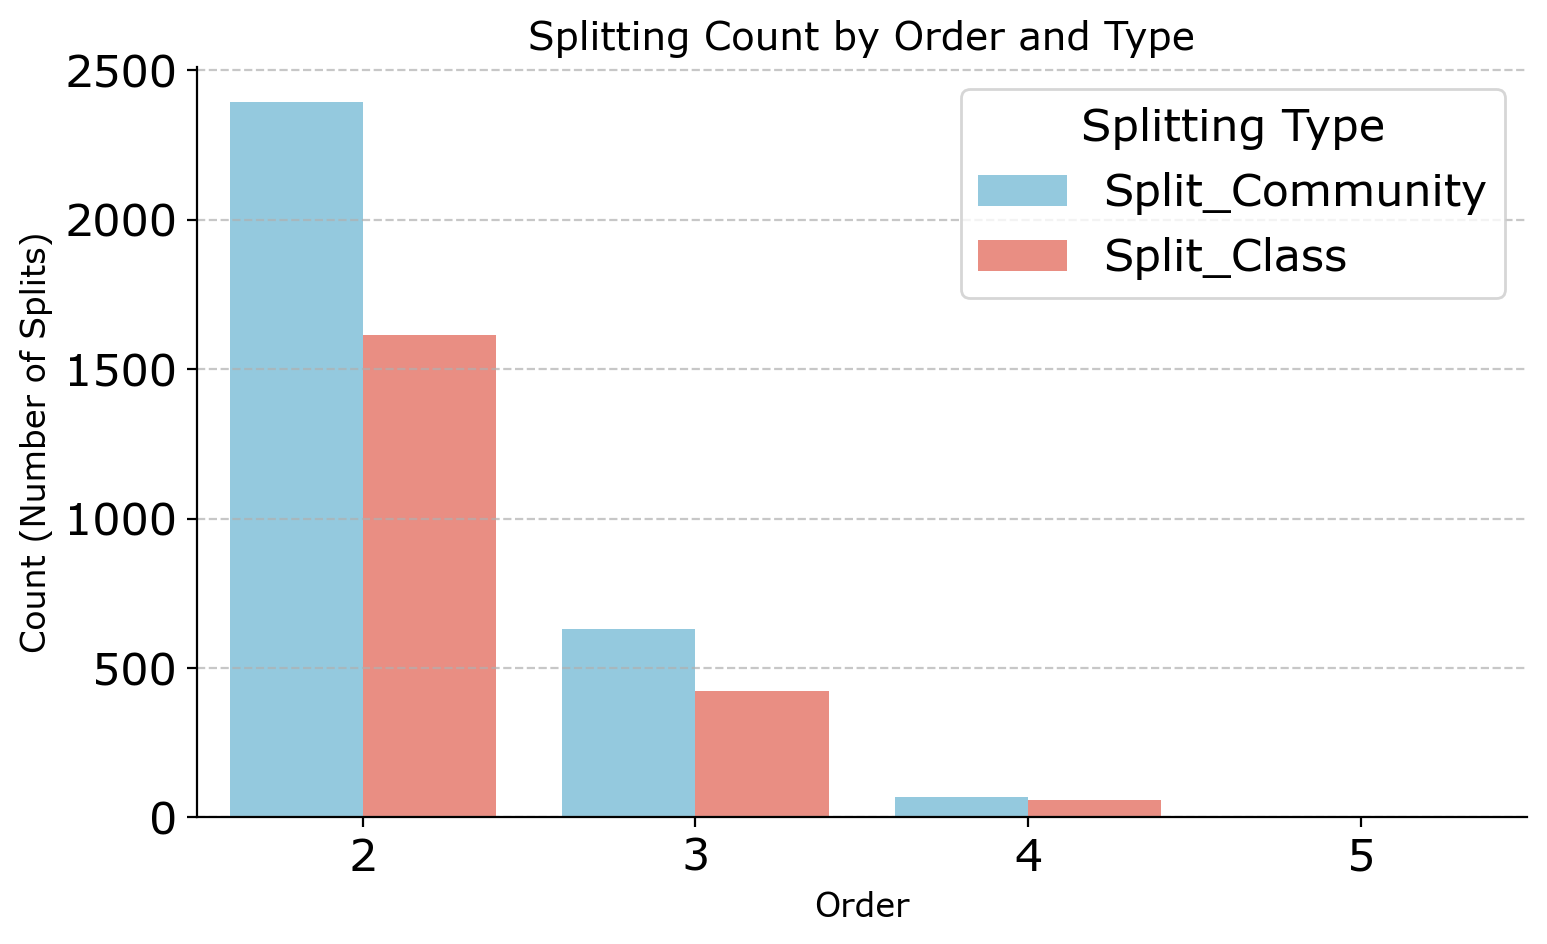

In [7]:
df = df_hedge_distribution
orders = [2, 3, 4, 5]
num_split_community_s = []
num_split_class_s = []
for o in [2, 3, 4, 5]:
    num_split_community = df[(df['Order']==o) & (df['Num_Community']>1)].shape[0]
    num_split_community_s.append(num_split_community)
    num_split_class = df[(df['Order']==o) & (df['Num_Class']>1)].shape[0]
    num_split_class_s.append(num_split_class)

df_results = pd.DataFrame({
    'Order': orders,
    'Split_Community': num_split_community_s,
    'Split_Class': num_split_class_s
})

# 2. 将宽格式转换为长格式 (使用 melt)
df_long = df_results.melt(
    id_vars='Order', 
    var_name='Split_Type', 
    value_name='Count'
)
print(df_long)

# ----------------------------------------------------
# 绘制条形图
# ----------------------------------------------------

plt.figure(figsize=(8, 5))

# 使用 Seaborn 的 barplot 绘制分组条形图
sns.barplot(
    data=df_long,
    x='Order',              # 横轴：Order
    y='Count',              # 纵轴：计数值
    hue='Split_Type',       # 分组变量：Community vs Class
    palette={'Split_Community': 'skyblue', 'Split_Class': 'salmon'}
)

# 格式化图表
plt.title('Splitting Count by Order and Type', fontsize=14)
plt.xlabel('Order', fontsize=12)
plt.ylabel('Count (Number of Splits)', fontsize=12)
plt.legend(title='Splitting Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

In [8]:
df = df_hedge_distribution
orders = [2, 3, 4, 5]
MaxNumNodes_SameCommunity = {o:dict() for o in orders}
MaxNumNodes_SameClass = {o:dict() for o in orders}
for o in [2, 3, 4, 5]:
    for max_num in range(1, o+1):
        a = df[(df['Order']==o) & (df['MaxNumNodes_SameCommunity']==max_num)].shape[0]
        MaxNumNodes_SameCommunity[o][max_num] = a
        b = df[(df['Order']==o) & (df['MaxNumNodes_SameClass']==max_num)].shape[0]
        MaxNumNodes_SameClass[o][max_num] = b
print("Community", MaxNumNodes_SameCommunity)
print("Class", MaxNumNodes_SameClass)

Community {2: {1: 2393, 2: 3105}, 3: {1: 58, 2: 573, 3: 1460}, 4: {1: 0, 2: 25, 3: 43, 4: 154}, 5: {1: 0, 2: 0, 3: 1, 4: 2, 5: 4}}
Class {2: {1: 1615, 2: 3883}, 3: {1: 50, 2: 372, 3: 1669}, 4: {1: 0, 2: 29, 3: 30, 4: 163}, 5: {1: 0, 2: 1, 3: 1, 4: 0, 5: 5}}


In [9]:
# 转换 MaxNumNodes_SameCommunity
df_community = pd.DataFrame.from_dict(MaxNumNodes_SameCommunity, orient='index')
df_community = df_community.fillna(0).astype(int)
matrix_community = df_community.values

# 转换 MaxNumNodes_SameClass
df_class = pd.DataFrame.from_dict(MaxNumNodes_SameClass, orient='index')
df_class = df_class.fillna(0).astype(int)
matrix_class = df_class.values

In [17]:
def _plot(matrix, ax=None, fontsize=14):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    # cmap = mpl.colormaps["seismic_r"]
    cmap = mpl.colormaps["PuRd"]
    # cmap = truncate_colormap(cmap, 0.3, 0.7)
    rowsum = np.sum(matrix, axis=1)
    rowsum = rowsum.reshape(-1, 1)
    rowsum = np.repeat(rowsum, np.shape(matrix)[1], axis=1)
    norm_matrix = np.round(matrix / rowsum, 2)
    print(norm_matrix)
    im = ax.matshow(norm_matrix, cmap=cmap, vmin=0, vmax=np.max(norm_matrix))
    for i in range(np.shape(norm_matrix)[0]):
        for j in range(np.shape(norm_matrix)[1]):
            c = norm_matrix[i,j]
            ax.text(j, i, str(np.round(c, 3) if c != 0 else 0), va='center', ha='center', fontsize=fontsize)
    return ax, cmap

In [64]:
print(matrix_community)
print(matrix_class)

[[2393 3105    0    0    0]
 [  58  573 1460    0    0]
 [   0   25   43  154    0]
 [   0    0    1    2    4]]
[[1615 3883    0    0    0]
 [  50  372 1669    0    0]
 [   0   29   30  163    0]
 [   0    1    1    0    5]]


[[0.44 0.56 0.   0.   0.  ]
 [0.03 0.27 0.7  0.   0.  ]
 [0.   0.11 0.19 0.69 0.  ]
 [0.   0.   0.14 0.29 0.57]]


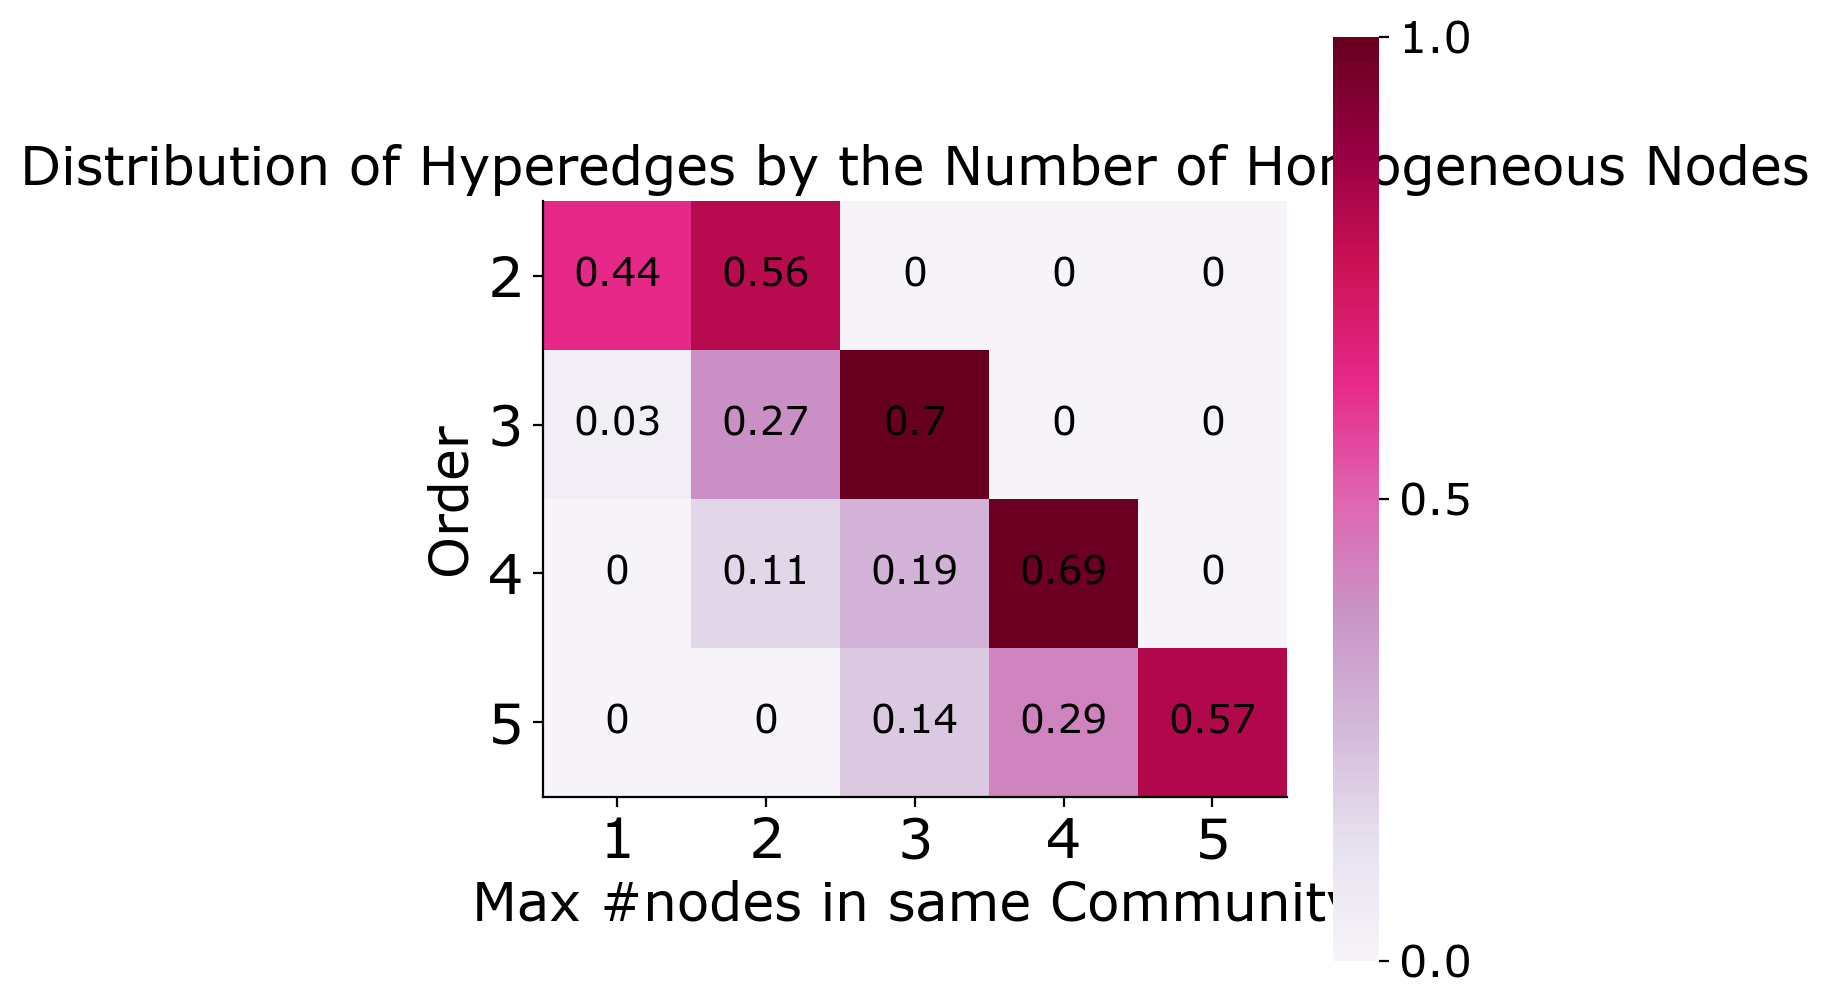

In [21]:
ax, cmap = _plot(matrix_community)
ax.set_xticks(np.arange(0, np.shape(matrix_community)[1]), np.arange(1, np.shape(matrix_community)[1]+1), fontsize=20)
ax.xaxis.set_ticks_position('bottom')
ax.set_yticks(np.arange(0, np.shape(matrix_community)[0]), orders, fontsize=20)
group = "Community"
ax.set_title(f'Distribution of Hyperedges by the Number of Homogeneous Nodes')
ax.set_xlabel(f"Max #nodes in same {group}")
ax.set_ylabel("Order")
n_bin= 1
ticks = [0, 0.5, 1]
cbar = plt.colorbar(ScalarMappable(cmap=cmap, norm=plt.Normalize(0, n_bin)), ticks=ticks, label='', ax=ax)
cbar.outline.set_visible(False)
save_path = "./_Figure/Hyper/" + "FigureHighschoolHomoHedgeDis_colorbar.pdf"
plt.savefig(save_path, dpi=600)

[[0.29 0.71 0.   0.   0.  ]
 [0.02 0.18 0.8  0.   0.  ]
 [0.   0.13 0.14 0.73 0.  ]
 [0.   0.14 0.14 0.   0.71]]


Text(0, 0.5, 'Order')

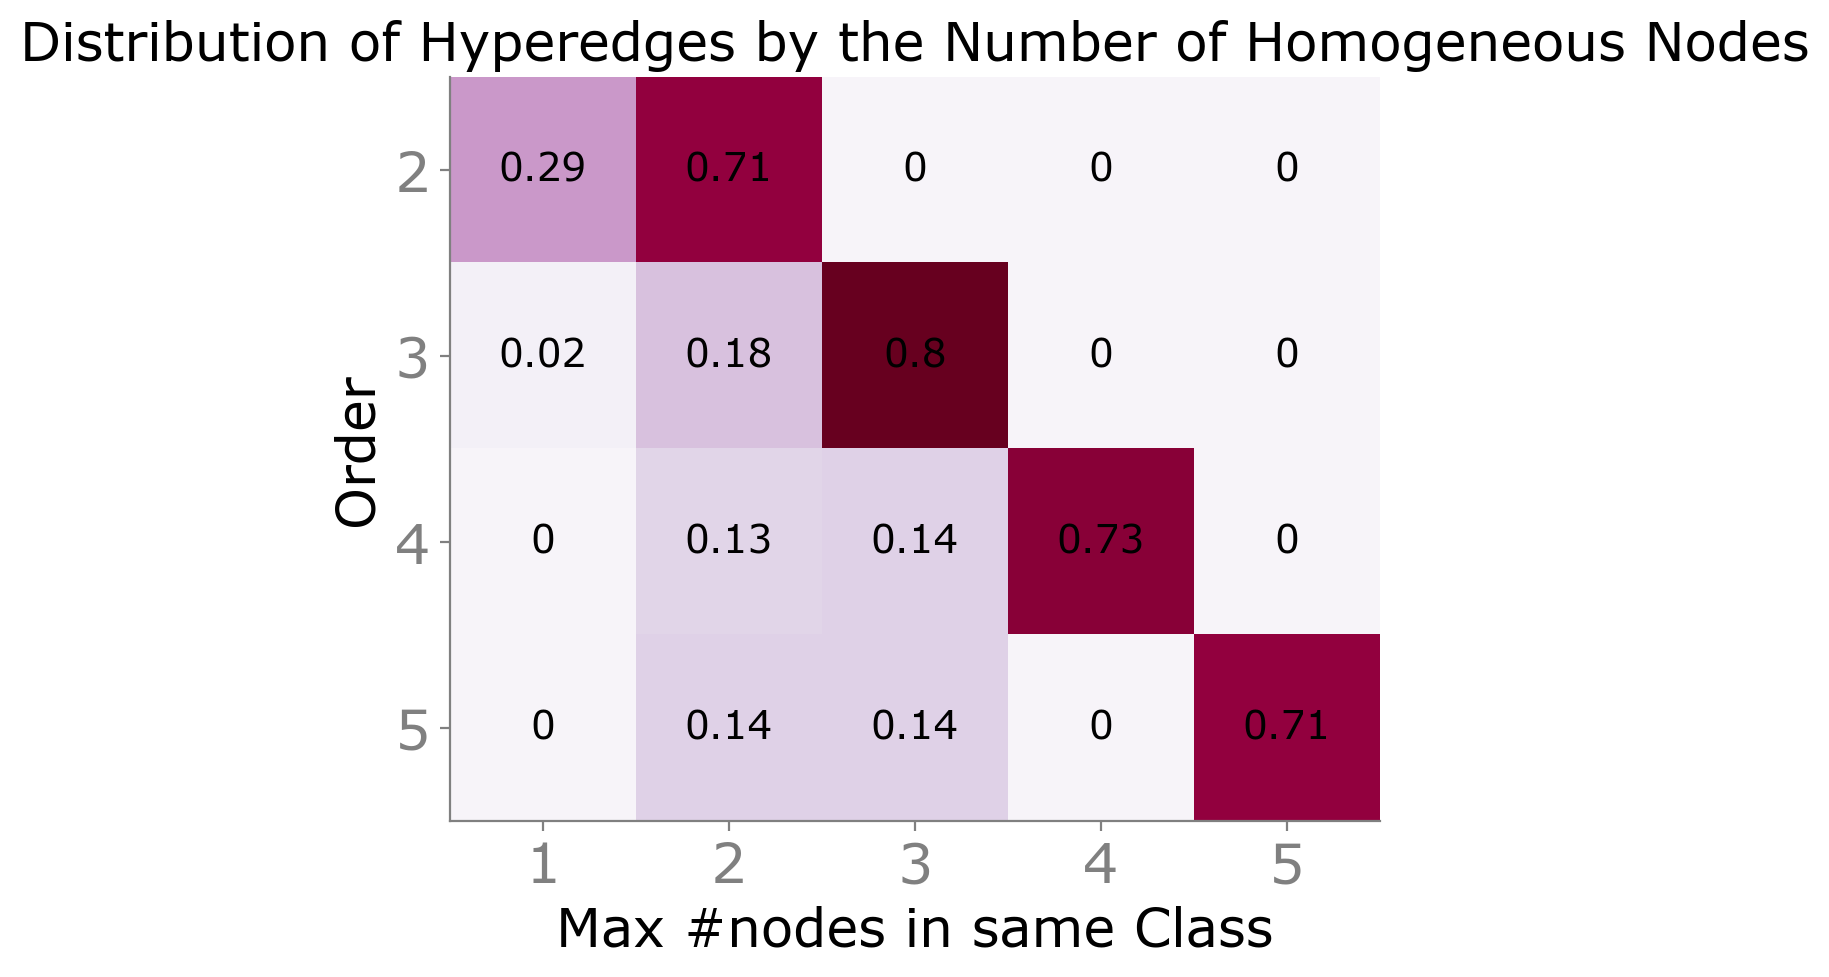

In [63]:
ax = _plot(matrix_class)
ax.set_xticks(np.arange(0, np.shape(matrix_class)[1]), np.arange(1, np.shape(matrix_class)[1]+1), fontsize=20)
ax.xaxis.set_ticks_position('bottom')
ax.set_yticks(np.arange(0, np.shape(matrix_class)[0]), orders, fontsize=20)
group = "Class"
ax.set_title(f'Distribution of Hyperedges by the Number of Homogeneous Nodes')
ax.set_xlabel(f"Max #nodes in same {group}")
ax.set_ylabel("Order")

[[0.44 0.56 0.   0.   0.  ]
 [0.03 0.27 0.7  0.   0.  ]
 [0.   0.11 0.19 0.69 0.  ]
 [0.   0.   0.14 0.29 0.57]]
[[0.29 0.71 0.   0.   0.  ]
 [0.02 0.18 0.8  0.   0.  ]
 [0.   0.13 0.14 0.73 0.  ]
 [0.   0.14 0.14 0.   0.71]]


TypeError: FigureBase.colorbar() missing 1 required positional argument: 'mappable'

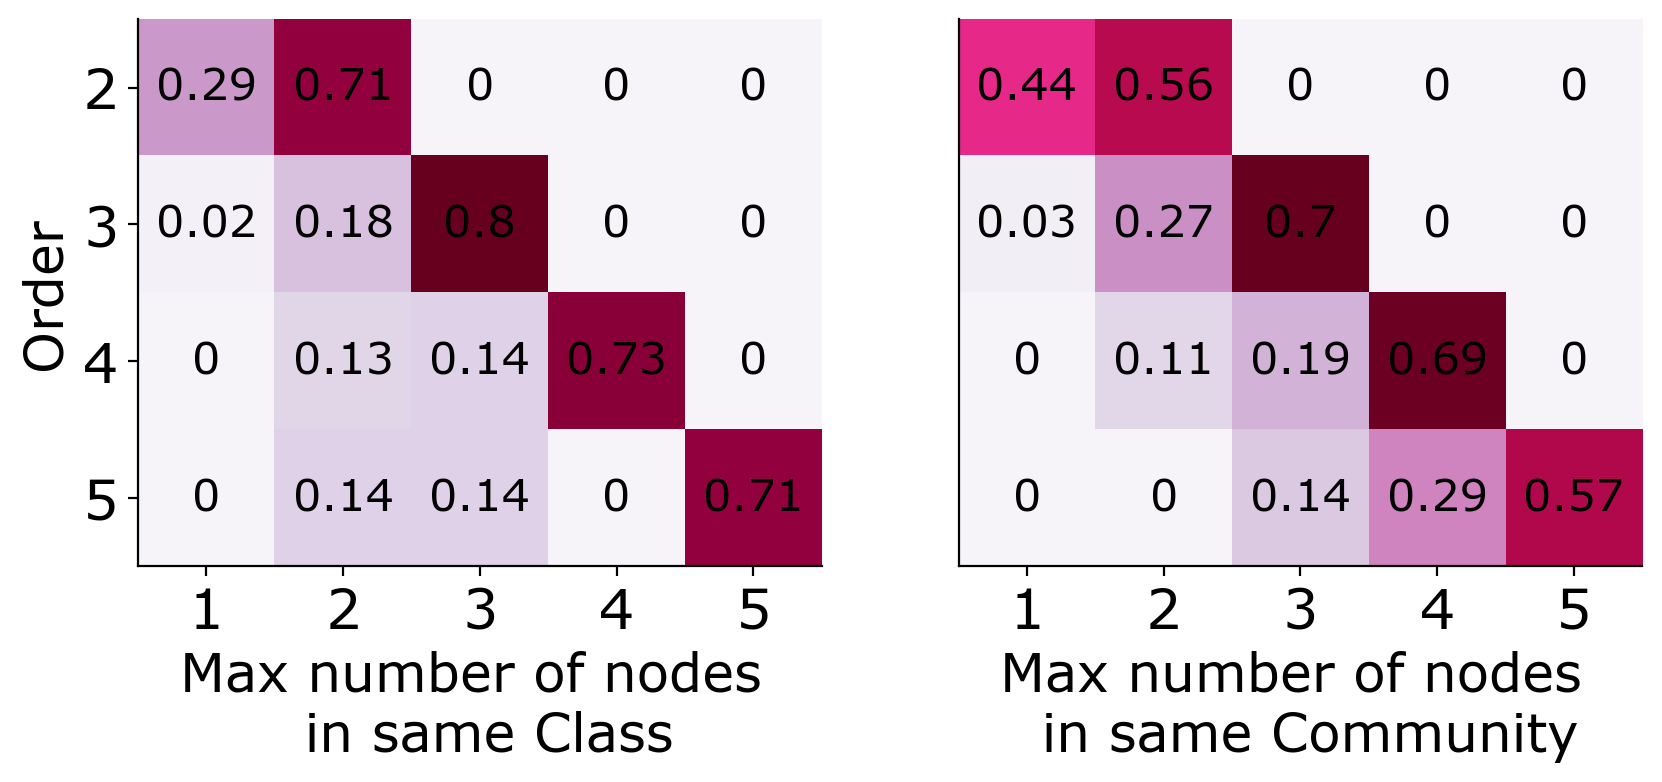

In [13]:
fig = plt.figure(figsize=(15, 4))
widths = [3,3,3]
heights = [3]
spec5 = fig.add_gridspec(ncols=3, nrows=1, width_ratios=widths, height_ratios=heights)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
_plot(matrix_community, ax=ax, fontsize=16)
ax.set_xticks(np.arange(0, np.shape(matrix_community)[1]), np.arange(1, np.shape(matrix_community)[1]+1), fontsize=20)
ax.xaxis.set_ticks_position('bottom')
# ax.set_yticks(np.arange(0, np.shape(matrix_community)[0]), orders, fontsize=20)
ax.set_yticks([])
group = "Community"
# ax.set_title(f'Distribution of Hyperedges by the Number of Homogeneous Nodes')
ax.set_xlabel(f"Max number of nodes \n in same {group}")
# ax.set_ylabel("Order")

row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
_plot(matrix_class, ax=ax, fontsize=16)
ax.set_xticks(np.arange(0, np.shape(matrix_class)[1]), np.arange(1, np.shape(matrix_class)[1]+1), fontsize=20)
ax.xaxis.set_ticks_position('bottom')
ax.set_yticks(np.arange(0, np.shape(matrix_class)[0]), orders, fontsize=20)
# ax.set_yticks([])
group = "Class"
# ax.set_title(f'Distribution of Hyperedges by the Number of Homogeneous Nodes')
ax.set_xlabel(f"Max number of nodes \n in same {group}")
ax.set_ylabel("Order")
# fig.colorbar()


row = 0
col = 2
ax = fig.add_subplot(spec5[row, col])
print(order_count)
y_pos = np.arange(4)
y_labels = [5, 4, 3, 2]
bars = ax.barh(y_pos, [order_count[y] for y in y_labels], color="#e98e83")
for bar in bars:
    plt.text(
        bar.get_width() + 50,  # X 坐标：条形末端 + 偏移
        bar.get_y() + bar.get_height()/2, # Y 坐标：条形中心
        str(int(bar.get_width())),
        ha='left',            # 水平对齐：靠左
        va='center',          # 垂直对齐：居中
        fontsize=10
    )
# ax.set_yticks(y_pos, y_labels)
ax.set_yticks([])
# ax.set_ylabel(f"Order")
ax.set_xlabel(f"Number of Hyperedges")

fig.tight_layout()
fig.align_xlabels()
save_path = "./_Figure/Hyper/" + "FigureHighschoolHomoHedgeDis_v1.pdf"
plt.savefig(save_path, dpi=600)